In [1]:
import torch
import torchvision
from torchvision import datasets, transforms

#Check if GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [2]:
import random
import numpy as np

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Random seeds set. ")

Random seeds set. 


In [3]:
#Define a transform to convert images to tensors and normalize them
transform = transforms.Compose([
    transforms.ToTensor(), #convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,)) #scale pixel values to [-1, 1]
])

#Download and load the training and test datasets
train_dataset = datasets.MNIST(
    root= "data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root= "data",
    train=False,
    transform=transform,
    download=True
)

#Use Dataloader to handle batching and shuffling
train_loader = torch.utils.data.DataLoader(
    dataset = train_dataset,
    batch_size = 64,
    shuffle = True
)
test_loader = torch.utils.data.DataLoader(
    dataset = test_dataset,
    batch_size = 64,
    shuffle = False
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 60000
Test samples: 10000


In [4]:
#Get one batch of training data
images, labels = next(iter(train_loader))

print("Batch image tensor shape:", images.shape)
print("Batch label tensor shape:", labels.shape)

print("First 10 labels: ", labels[:10].tolist())

Batch image tensor shape: torch.Size([64, 1, 28, 28])
Batch label tensor shape: torch.Size([64])
First 10 labels:  [1, 2, 8, 5, 2, 6, 9, 9, 9, 4]


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        # First convolution: 1 input channel (grayscale), 32 output channels, 3x3 kernel
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        # Second convolution: 32 input channels, 64 output channels, 3x3 kernel
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        # Fully connected layer: input features -> 128 neurons
        self.fc1 = nn.Linear(64 * 5 * 5, 128)  # 64 feature maps of size 5x5
        # Output layer: 128 neurons -> 10 classes (digits 0–9)
        self.fc2 = nn.Linear(128, 10)

    def forward(self,x):
        #Convolution to ReLU to Pooling
        x = F.relu(self.conv1(x)) #Apply first convolution and ReLU activation
        x = F.max_pool2d(x,2) #Apply 2x2 max

        #Convolution to ReLU to Pooling
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x,2)

        #Flatten
        x= x.view(x.size(0), -1)

        #Fully connected to ReLU
        x = F.relu(self.fc1(x))

        #Output layer (we don't need softmax here, as is handled by loss functions)
        x = self.fc2(x)
        return x

In [6]:
#Create model instance and move it to device (Gpu if available else Cpu)
model = Net().to(device)

#Loss function: CrossEntropyLoss is standard for multi-class classification
criterion = nn.CrossEntropyLoss()

#Optimizer: Using Adam since it works well with CNNs
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:
num_epochs = 10  # how many times we go through the dataset

for epoch in range(num_epochs):
    model.train()  # set model to training mode
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to CPU/GPU
        images, labels = images.to(device), labels.to(device)

        # 1. Zero the gradients (reset from previous batch)
        optimizer.zero_grad()

        # 2. Forward pass (get predictions)
        outputs = model(images)

        # 3. Compute loss
        loss = criterion(outputs, labels)

        # 4. Backward pass (compute gradients)
        loss.backward()

        # 5. Update weights
        optimizer.step()

        # Track loss
        running_loss += loss.item()

        if (batch_idx+1) % 100 == 0:  # print every 100 batches
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    # Average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] finished. Avg Loss: {epoch_loss:.4f}\n")


Epoch [1/10], Step [100/938], Loss: 0.0070
Epoch [1/10], Step [200/938], Loss: 0.0040
Epoch [1/10], Step [300/938], Loss: 0.0014
Epoch [1/10], Step [400/938], Loss: 0.0021
Epoch [1/10], Step [500/938], Loss: 0.0002
Epoch [1/10], Step [600/938], Loss: 0.0134
Epoch [1/10], Step [700/938], Loss: 0.0164
Epoch [1/10], Step [800/938], Loss: 0.0002
Epoch [1/10], Step [900/938], Loss: 0.0004
Epoch [1/10] finished. Avg Loss: 0.0122

Epoch [2/10], Step [100/938], Loss: 0.0157
Epoch [2/10], Step [200/938], Loss: 0.0004
Epoch [2/10], Step [300/938], Loss: 0.0017
Epoch [2/10], Step [400/938], Loss: 0.0108
Epoch [2/10], Step [500/938], Loss: 0.0318
Epoch [2/10], Step [600/938], Loss: 0.0008
Epoch [2/10], Step [700/938], Loss: 0.0010
Epoch [2/10], Step [800/938], Loss: 0.0036
Epoch [2/10], Step [900/938], Loss: 0.0511
Epoch [2/10] finished. Avg Loss: 0.0116

Epoch [3/10], Step [100/938], Loss: 0.0031
Epoch [3/10], Step [200/938], Loss: 0.0050
Epoch [3/10], Step [300/938], Loss: 0.0058
Epoch [3/10], S

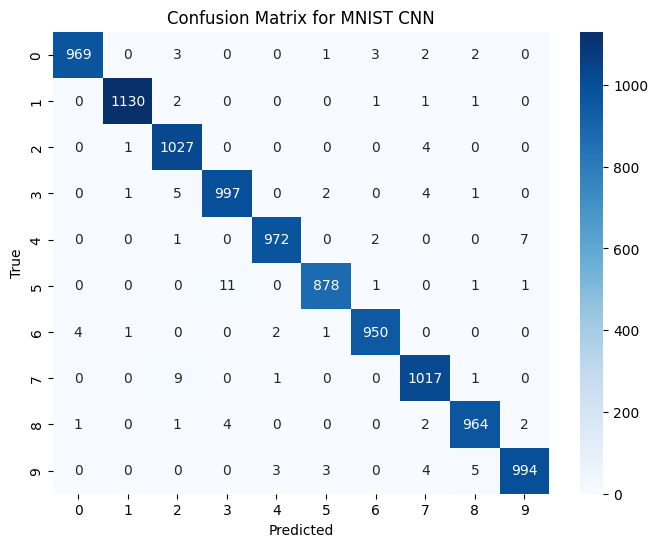

Classification Report (per digit):
              precision    recall  f1-score   support

           0      0.995     0.989     0.992       980
           1      0.997     0.996     0.996      1135
           2      0.980     0.995     0.988      1032
           3      0.985     0.987     0.986      1010
           4      0.994     0.990     0.992       982
           5      0.992     0.984     0.988       892
           6      0.993     0.992     0.992       958
           7      0.984     0.989     0.986      1028
           8      0.989     0.990     0.989       974
           9      0.990     0.985     0.988      1009

    accuracy                          0.990     10000
   macro avg      0.990     0.990     0.990     10000
weighted avg      0.990     0.990     0.990     10000



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Step 1: Collect all true labels and predictions ----
all_labels = []   # will store true digit labels
all_preds = []    # will store model predictions

model.eval()  # set model to evaluation mode (important!)
with torch.no_grad():  # no gradients needed for evaluation
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass: model makes predictions
        outputs = model(images)

        # Take the class with the highest score as prediction
        _, predicted = torch.max(outputs, 1)

        # Move tensors to CPU and convert to numpy arrays for sklearn
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# ---- Step 2: Confusion Matrix ----
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[str(i) for i in range(10)],  # predicted digits
    yticklabels=[str(i) for i in range(10)]   # true digits
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for MNIST CNN")
plt.show()

# ---- Step 3: Precision / Recall / F1 ----
print("Classification Report (per digit):")
print(classification_report(all_labels, all_preds, digits=3))


In [11]:
# Save only the trained weights (state_dict)
torch.save(model.state_dict(), "models/cnn_mnist.pth")
print("Model saved to models/cnn_mnist.pth")


Model saved to models/cnn_mnist.pth


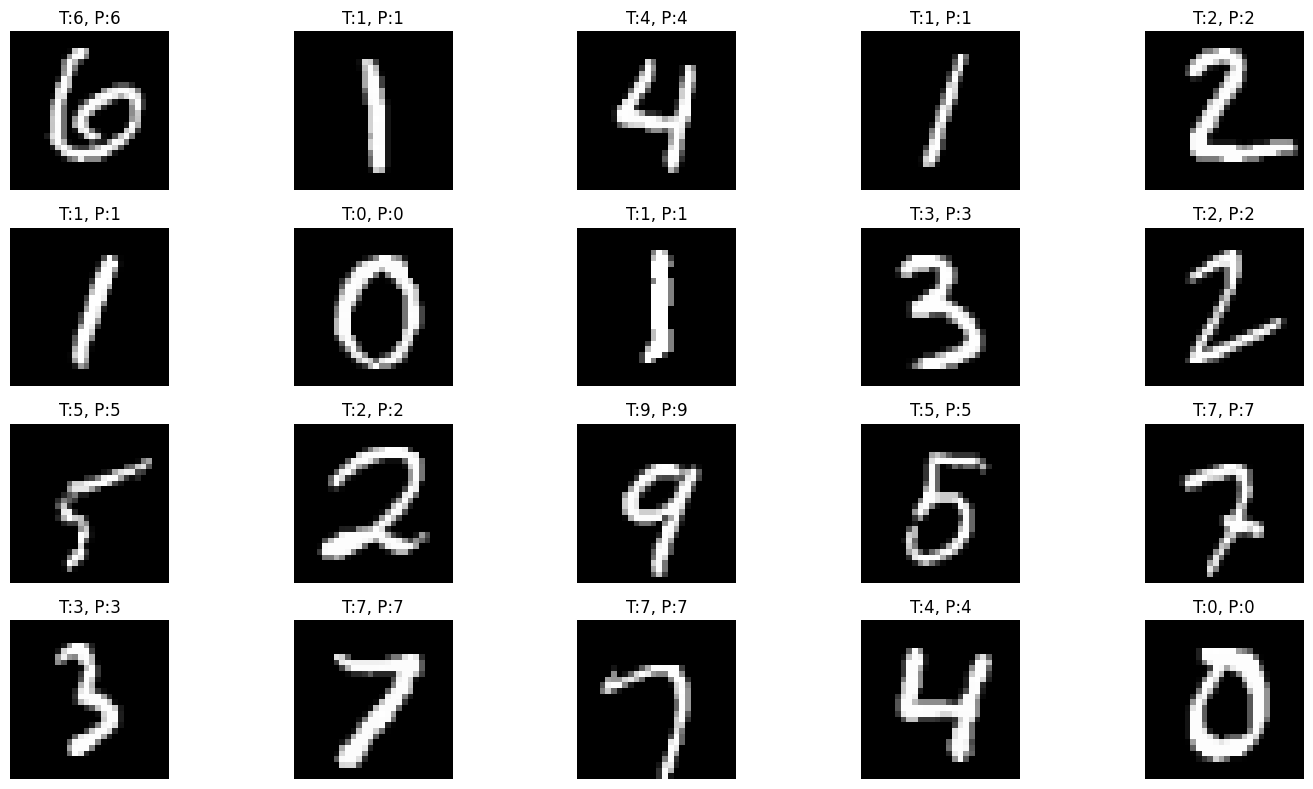

In [46]:
import matplotlib.pyplot as plt
import random

# Get one full batch from test_loader
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# Pick 10 random indices from this batch
indices = random.sample(range(len(images)), 20)

model.eval()
plt.figure(figsize=(15, 8))

for i, idx in enumerate(indices):
    img = images[idx].unsqueeze(0)   # add batch dimension
    label = labels[idx].item()

    with torch.no_grad():
        output = model(img)
        _, predicted = torch.max(output, 1)
        predicted_digit = predicted.item()

    # Plot image
    plt.subplot(4, 5, i+1)  # 4 rows × 5 columns
    plt.imshow(images[idx].cpu().squeeze(), cmap="gray")
    plt.title(f"T:{label}, P:{predicted_digit}")
    plt.axis("off")

plt.tight_layout()
plt.show()


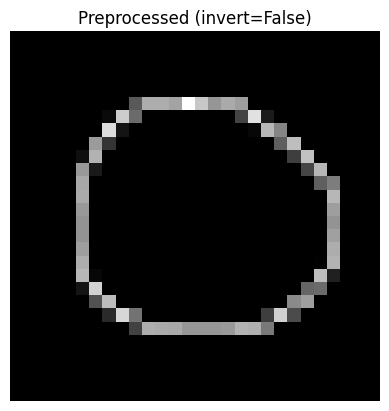

Predicted Digit: 2


In [44]:
import cv2, numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

def preprocess_digit(img_path, device="cpu", debug=False):
    # 1) Load grayscale
    img = Image.open(img_path).convert("L")
    arr = np.array(img).astype(np.uint8)

    # 2) Auto-polarity: if background is mostly light, invert so background becomes black
    invert_needed = arr.mean() > 127  # white-ish background -> invert
    if invert_needed:
        arr = 255 - arr

    # 3) Binarize (foreground white=255, background black=0)
    _, arr = cv2.threshold(arr, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4) Fill gaps & thicken (morphological closing + light dilation)
    kernel = np.ones((3,3), np.uint8)
    arr = cv2.morphologyEx(arr, cv2.MORPH_CLOSE, kernel, iterations=1)
    arr = cv2.dilate(arr, kernel, iterations=1)

    # 5) Crop to bounding box of foreground
    coords = cv2.findNonZero(arr)
    if coords is None:
        # fallback: blank; return a black 28x28
        arr = np.zeros((28,28), dtype=np.uint8)
    else:
        x, y, w, h = cv2.boundingRect(coords)
        arr = arr[y:y+h, x:x+w]

        # 6) Keep aspect ratio, resize longest side to 20
        h0, w0 = arr.shape
        if h0 >= w0:
            new_h, new_w = 20, max(1, int(round(w0 * (20.0 / h0))))
        else:
            new_w, new_h = 20, max(1, int(round(h0 * (20.0 / w0))))
        arr = cv2.resize(arr, (new_w, new_h), interpolation=cv2.INTER_AREA)

        # 7) Pad to 28×28 (center roughly)
        pad_top = (28 - new_h) // 2
        pad_bottom = 28 - new_h - pad_top
        pad_left = (28 - new_w) // 2
        pad_right = 28 - new_w - pad_left
        arr = cv2.copyMakeBorder(arr, pad_top, pad_bottom, pad_left, pad_right,
                                 cv2.BORDER_CONSTANT, value=0)

        # 8) Center-of-mass shift to (14,14) for MNIST-like centering
        ys, xs = np.where(arr > 0)
        if len(xs) > 0:
            cx, cy = xs.mean(), ys.mean()
            shift_x = int(round(14 - cx))
            shift_y = int(round(14 - cy))
            M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
            arr = cv2.warpAffine(arr, M, (28, 28), flags=cv2.INTER_NEAREST, borderValue=0)

    if debug:
        plt.imshow(arr, cmap="gray")
        plt.title(f"Preprocessed (invert={invert_needed})")
        plt.axis("off")
        plt.show()

    # 9) To tensor, normalize like training: [-1, 1]
    pil28 = Image.fromarray(arr)
    tfm = transforms.Compose([
        transforms.ToTensor(),                  # [0,1]
        transforms.Normalize((0.5,), (0.5,))    # -> [-1,1]
    ])
    tensor = tfm(pil28).unsqueeze(0).to(device)  # [1,1,28,28]
    return tensor


img_tensor = preprocess_digit("my_digit.png", device, debug=True)

model.eval()
with torch.no_grad():
    out = model(img_tensor)
    _, pred = torch.max(out, 1)
    print("Predicted Digit:", pred.item())
